### ideal IO

In [3]:
import os
import numpy as np
import pandas as pd

file_path = './test_results_v4.xlsx'

df_raw = pd.read_excel(file_path, engine='openpyxl')
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains("Unnamed:")]

# file_path2 = './test_results_v4_io.xlsx'
# df_raw_io = pd.read_excel(file_path2, engine='openpyxl')
# df_raw = pd.concat([df_raw, df_raw_io], ignore_index=True)

/tmp/ipykernel_2297/30017551.py:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(len(all_noise_labels), 1))


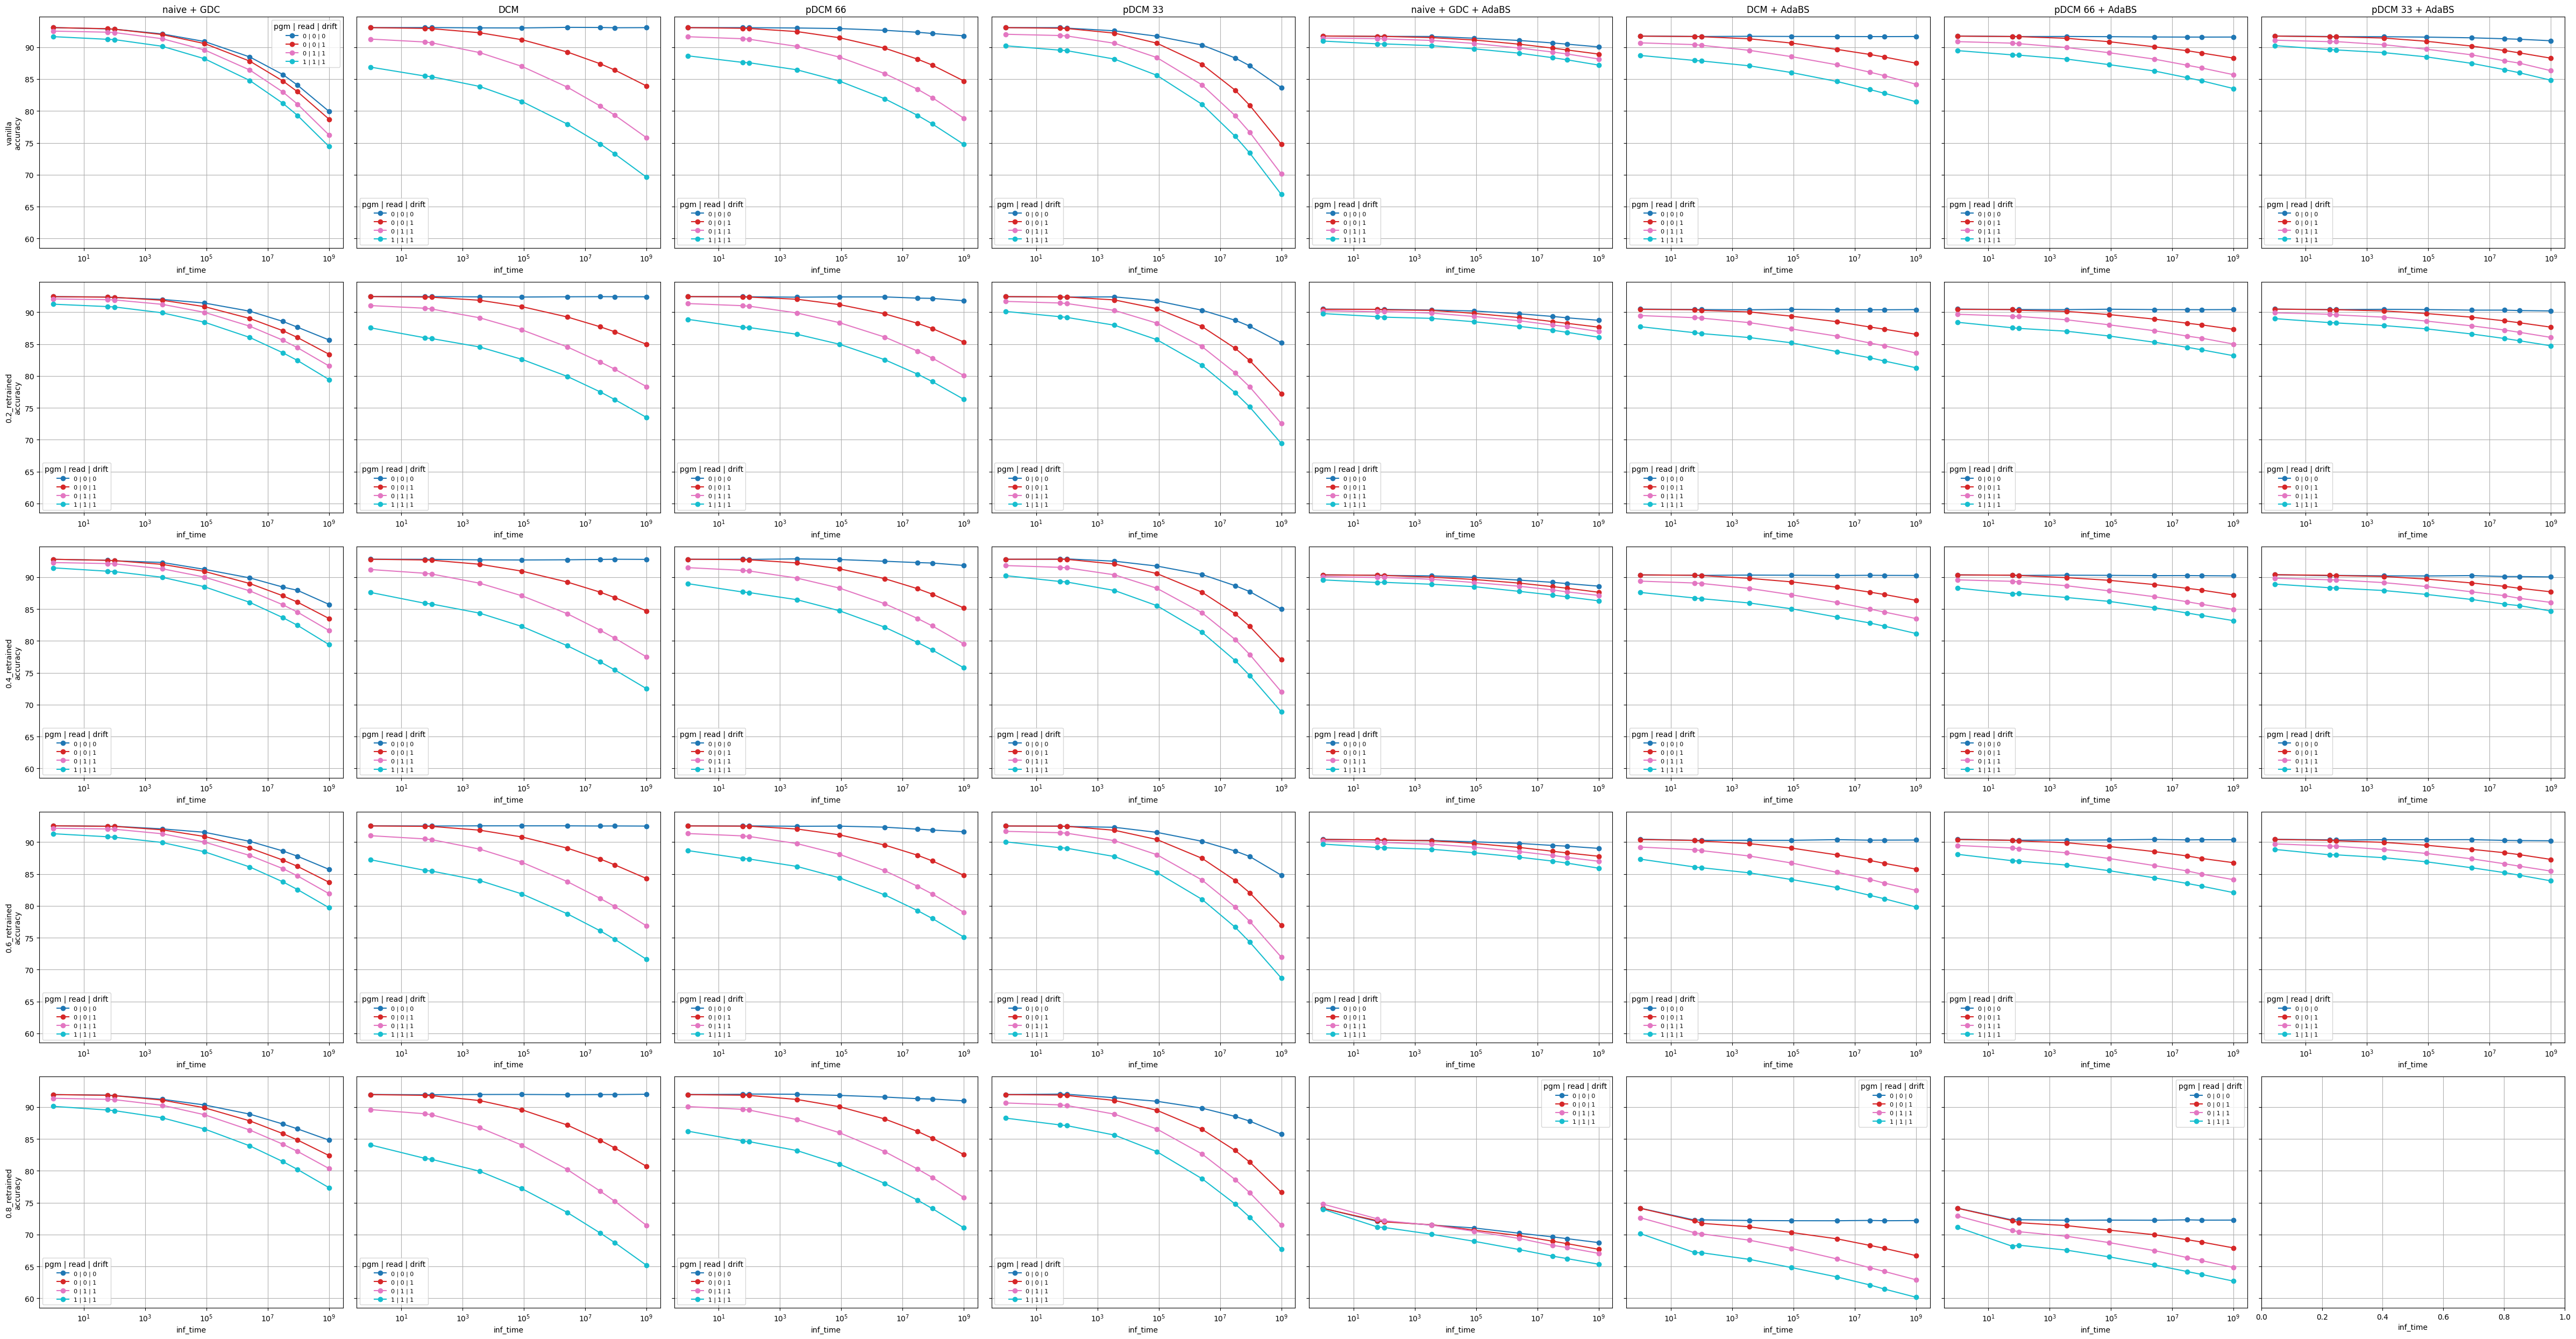

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_filtered = df_raw.copy()
df_filtered = df_filtered[df_filtered['GDC'] == 'on']
df_filtered = df_filtered[df_filtered['IOparameter'] == 'ideal']
df_filtered = df_filtered[df_filtered['drift_noise_scale'].isin([0, 1])]

def is_missing_like(series):
    return series.isna() | series.astype(str).str.lower().isin(['nan', 'none', '-'])

conditions = [
    (
        'naive + GDC',
        (df_filtered['mapping_method'] == 'naive')
        & (df_filtered['alpha'] == 'GDC')
        & is_missing_like(df_filtered['distortion_f'])
        & is_missing_like(df_filtered['AdaBS'])
    ),
    (
        'DCM',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0')
        & is_missing_like(df_filtered['AdaBS'])
    ),
    (
        'pDCM 66',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0.333')
        & is_missing_like(df_filtered['AdaBS'])
    ),
        (
        'pDCM 33',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0.667')
        & is_missing_like(df_filtered['AdaBS'])
    ),
    (
        'naive + GDC + AdaBS',
        (df_filtered['mapping_method'] == 'naive')
        & (df_filtered['alpha'] == 'GDC')
        & is_missing_like(df_filtered['distortion_f'])
        & (~is_missing_like(df_filtered['AdaBS']))
    ),
    (
        'DCM + AdaBS',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0')
        & (~is_missing_like(df_filtered['AdaBS']))
    ),
    (
        'pDCM 66 + AdaBS',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0.333')
        & (~is_missing_like(df_filtered['AdaBS']))
    ),
    (
        'pDCM 33 + AdaBS',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0.667')
        & (~is_missing_like(df_filtered['AdaBS']))
    ),
]

noise_cols = ['pgm_noise_scale', 'read_noise_scale', 'drift_noise_scale']
condition_dfs = []

for condition_name, condition_mask in conditions:
    condition_df = df_filtered[condition_mask].copy()
    condition_df['condition_name'] = condition_name
    condition_df['noise_label'] = condition_df[noise_cols].astype(str).agg(' | '.join, axis=1)
    condition_dfs.append(condition_df)

plot_df = pd.concat(condition_dfs, ignore_index=True)

model_type_order = ['vanilla']  # 먼저 오게 할 것들
remaining_model_types = sorted([m for m in plot_df['model_type'].dropna().unique() if m not in model_type_order])
model_types = model_type_order + remaining_model_types
all_noise_labels = sorted(plot_df['noise_label'].dropna().unique())

cmap = plt.cm.get_cmap('tab10', max(len(all_noise_labels), 1))
color_map = {label: cmap(i) for i, label in enumerate(all_noise_labels)}

fig, axes = plt.subplots(
    len(model_types),
    len(conditions),
    figsize=(6 * len(conditions), 5 * len(model_types)),
    sharey=True,
    squeeze=False
)

for row_idx, model_type in enumerate(model_types):
    for col_idx, (condition_name, _) in enumerate(conditions):
        ax = axes[row_idx][col_idx]

        subset = plot_df[
            (plot_df['model_type'] == model_type) &
            (plot_df['condition_name'] == condition_name)
        ].sort_values('inf_time')

        for noise_label in all_noise_labels:
            line_df = subset[subset['noise_label'] == noise_label].sort_values('inf_time')
            if line_df.empty:
                continue

            ax.plot(
                line_df['inf_time'],
                line_df['accuracy'],
                marker='o',
                label=noise_label,
                color=color_map[noise_label]
            )

        if row_idx == 0:
            ax.set_title(condition_name)

        ax.set_xlabel('inf_time')
        ax.grid(True)

        if subset['inf_time'].gt(0).any():
            ax.set_xscale('log')

        if col_idx == 0:
            ax.set_ylabel(f'{model_type}\naccuracy')

        if not subset.empty:
            ax.legend(title='pgm | read | drift', fontsize=8)

plt.tight_layout()
plt.show()

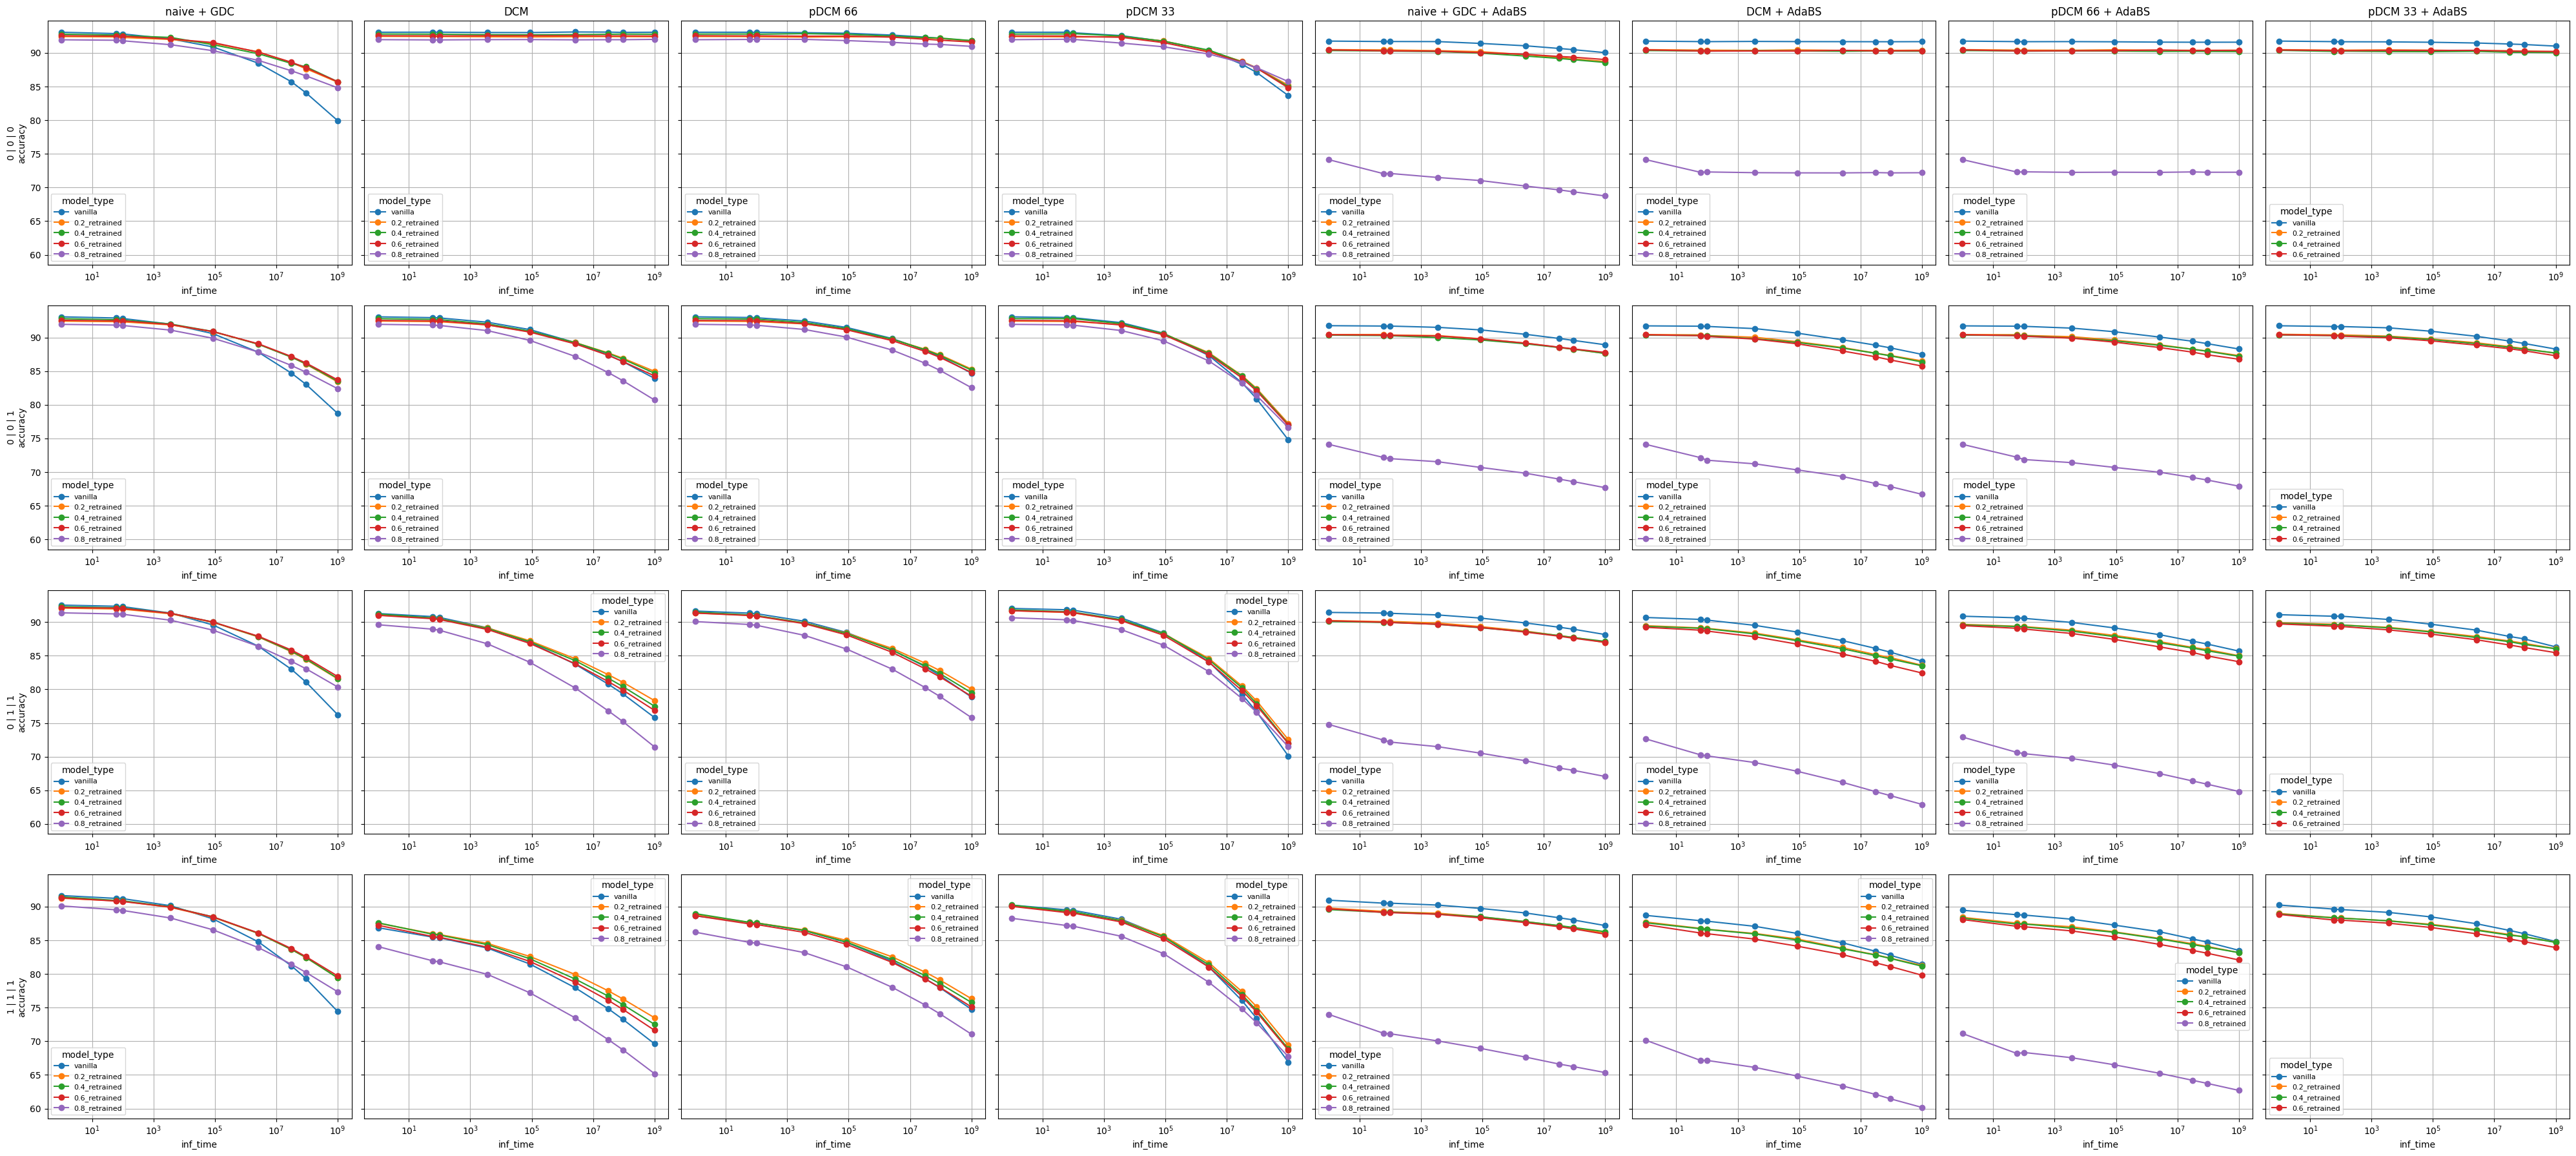

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_filtered = df_raw.copy()
df_filtered = df_filtered[df_filtered['GDC'] == 'on']
df_filtered = df_filtered[df_filtered['IOparameter'] == 'ideal']
df_filtered = df_filtered[df_filtered['drift_noise_scale'].isin([0, 1])]

def is_missing_like(series):
    return series.isna() | series.astype(str).str.lower().isin(['nan', 'none', '-'])

conditions = [
    (
        'naive + GDC',
        (df_filtered['mapping_method'] == 'naive')
        & (df_filtered['alpha'] == 'GDC')
        & is_missing_like(df_filtered['distortion_f'])
        & is_missing_like(df_filtered['AdaBS'])
    ),
    (
        'DCM',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0')
        & is_missing_like(df_filtered['AdaBS'])
    ),
    (
        'pDCM 66',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0.333')
        & is_missing_like(df_filtered['AdaBS'])
    ),
    (
        'pDCM 33',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0.667')
        & is_missing_like(df_filtered['AdaBS'])
    ),
    (
        'naive + GDC + AdaBS',
        (df_filtered['mapping_method'] == 'naive')
        & (df_filtered['alpha'] == 'GDC')
        & is_missing_like(df_filtered['distortion_f'])
        & (~is_missing_like(df_filtered['AdaBS']))
    ),
    (
        'DCM + AdaBS',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0')
        & (~is_missing_like(df_filtered['AdaBS']))
    ),
    (
        'pDCM 66 + AdaBS',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0.333')
        & (~is_missing_like(df_filtered['AdaBS']))
    ),
    (
        'pDCM 33 + AdaBS',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0.667')
        & (~is_missing_like(df_filtered['AdaBS']))
    ),
    
]

noise_cols = ['pgm_noise_scale', 'read_noise_scale', 'drift_noise_scale']
condition_dfs = []

for condition_name, condition_mask in conditions:
    condition_df = df_filtered[condition_mask].copy()
    condition_df['condition_name'] = condition_name
    condition_df['noise_label'] = condition_df[noise_cols].astype(str).agg(' | '.join, axis=1)
    condition_dfs.append(condition_df)

plot_df = pd.concat(condition_dfs, ignore_index=True)

model_type_order = ['vanilla']
remaining_model_types = sorted(
    [m for m in plot_df['model_type'].dropna().unique() if m not in model_type_order]
)
model_types = model_type_order + remaining_model_types

noise_labels = sorted(plot_df['noise_label'].dropna().unique())

cmap = plt.colormaps['tab10']
color_map = {model_type: cmap(i) for i, model_type in enumerate(model_types)}

fig, axes = plt.subplots(
    len(noise_labels),          # row = noise_label
    len(conditions),            # column = condition
    figsize=(5 * len(conditions), 4.5 * len(noise_labels)),
    sharey=True,
    squeeze=False
)

for row_idx, noise_label in enumerate(noise_labels):
    for col_idx, (condition_name, _) in enumerate(conditions):
        ax = axes[row_idx][col_idx]

        subset = plot_df[
            (plot_df['condition_name'] == condition_name) &
            (plot_df['noise_label'] == noise_label)
        ].sort_values('inf_time')

        for model_type in model_types:
            line_df = subset[subset['model_type'] == model_type].sort_values('inf_time')
            if line_df.empty:
                continue

            ax.plot(
                line_df['inf_time'],
                line_df['accuracy'],
                marker='o',
                label=model_type,
                color=color_map[model_type]
            )

        if row_idx == 0:
            ax.set_title(condition_name)

        if col_idx == 0:
            ax.set_ylabel(f'{noise_label}\naccuracy')

        ax.set_xlabel('inf_time')
        ax.grid(True)

        if subset['inf_time'].gt(0).any():
            ax.set_xscale('log')

        if not subset.empty:
            ax.legend(title='model_type', fontsize=8)

plt.tight_layout()
plt.show()

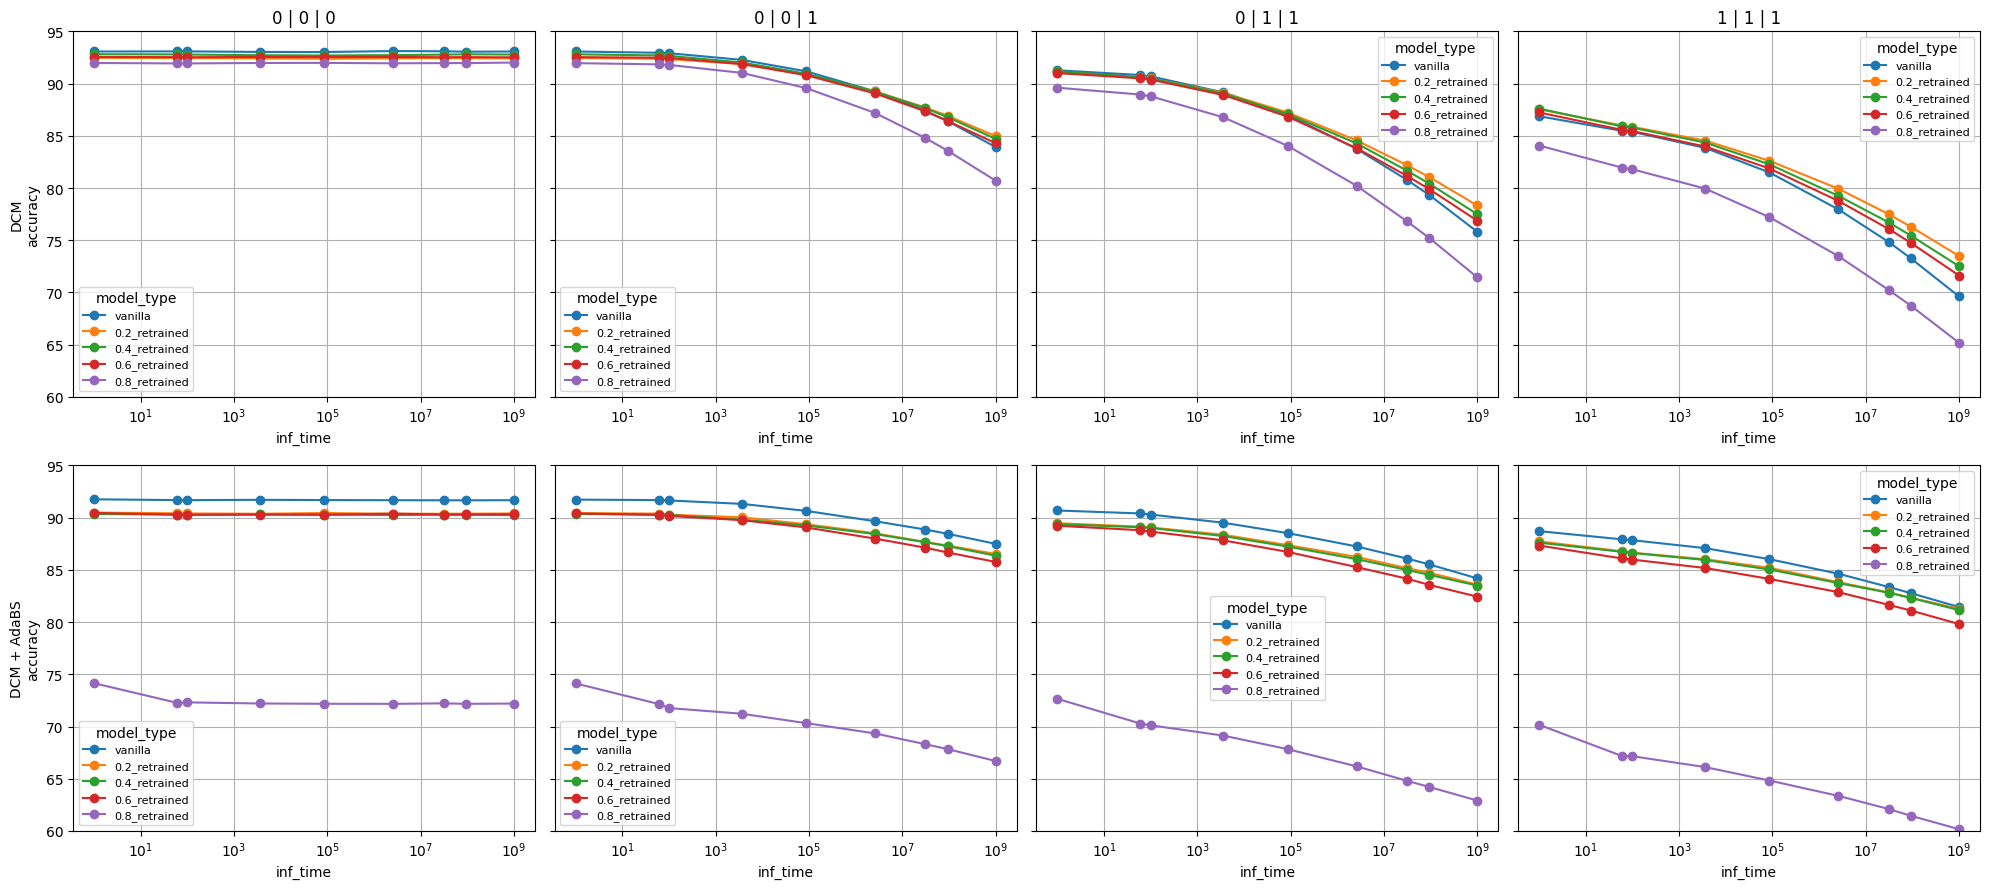

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_filtered = df_raw.copy()
df_filtered = df_filtered[df_filtered['GDC'] == 'on']
df_filtered = df_filtered[df_filtered['IOparameter'] == 'ideal']
df_filtered = df_filtered[df_filtered['drift_noise_scale'].isin([0, 1])]

def is_missing_like(series):
    return series.isna() | series.astype(str).str.lower().isin(['nan', 'none', '-'])

conditions = [
    # (
    #     'naive + GDC',
    #     (df_filtered['mapping_method'] == 'naive')
    #     & (df_filtered['alpha'] == 'GDC')
    #     & is_missing_like(df_filtered['distortion_f'])
    #     & is_missing_like(df_filtered['AdaBS'])
    # ),
    (
        'DCM',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0')
        & is_missing_like(df_filtered['AdaBS'])
    ),
    # (
    #     'pDCM 66',
    #     (df_filtered['mapping_method'] == 'DCM')
    #     & (df_filtered['alpha'].astype(str) == '0.024')
    #     & (df_filtered['distortion_f'].astype(str) == '0.333')
    #     & is_missing_like(df_filtered['AdaBS'])
    # ),
    # (
    #     'pDCM 33',
    #     (df_filtered['mapping_method'] == 'DCM')
    #     & (df_filtered['alpha'].astype(str) == '0.024')
    #     & (df_filtered['distortion_f'].astype(str) == '0.667')
    #     & is_missing_like(df_filtered['AdaBS'])
    # ),
    # (
    #     'naive + GDC + AdaBS',
    #     (df_filtered['mapping_method'] == 'naive')
    #     & (df_filtered['alpha'] == 'GDC')
    #     & is_missing_like(df_filtered['distortion_f'])
    #     & (~is_missing_like(df_filtered['AdaBS']))
    # ),
    (
        'DCM + AdaBS',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0')
        & (~is_missing_like(df_filtered['AdaBS']))
    ),
    # (
    #     'pDCM 66 + AdaBS',
    #     (df_filtered['mapping_method'] == 'DCM')
    #     & (df_filtered['alpha'].astype(str) == '0.024')
    #     & (df_filtered['distortion_f'].astype(str) == '0.333')
    #     & (~is_missing_like(df_filtered['AdaBS']))
    # ),
    # (
    #     'pDCM 33 + AdaBS',
    #     (df_filtered['mapping_method'] == 'DCM')
    #     & (df_filtered['alpha'].astype(str) == '0.024')
    #     & (df_filtered['distortion_f'].astype(str) == '0.667')
    #     & (~is_missing_like(df_filtered['AdaBS']))
    # ),
    
]

noise_cols = ['pgm_noise_scale', 'read_noise_scale', 'drift_noise_scale']
condition_dfs = []

for condition_name, condition_mask in conditions:
    condition_df = df_filtered[condition_mask].copy()
    condition_df['condition_name'] = condition_name
    condition_df['noise_label'] = condition_df[noise_cols].astype(str).agg(' | '.join, axis=1)
    condition_dfs.append(condition_df)

plot_df = pd.concat(condition_dfs, ignore_index=True)

model_type_order = ['vanilla']
remaining_model_types = sorted(
    [m for m in plot_df['model_type'].dropna().unique() if m not in model_type_order]
)
model_types = model_type_order + remaining_model_types

noise_labels = sorted(plot_df['noise_label'].dropna().unique())

cmap = plt.colormaps['tab10']
color_map = {model_type: cmap(i) for i, model_type in enumerate(model_types)}

fig, axes = plt.subplots(
    len(conditions),            # row = condition
    len(noise_labels),          # column = noise_label
    figsize=(5 * len(noise_labels), 4.5 * len(conditions)),
    sharey=True,
    squeeze=False
)

for row_idx, (condition_name, _) in enumerate(conditions):
    for col_idx, noise_label in enumerate(noise_labels):
        ax = axes[row_idx][col_idx]

        subset = plot_df[
            (plot_df['condition_name'] == condition_name) &
            (plot_df['noise_label'] == noise_label)
        ].sort_values('inf_time')

        for model_type in model_types:
            line_df = subset[subset['model_type'] == model_type].sort_values('inf_time')
            if line_df.empty:
                continue

            ax.plot(
                line_df['inf_time'],
                line_df['accuracy'],
                marker='o',
                label=model_type,
                color=color_map[model_type]
            )

        if row_idx == 0:
            ax.set_title(noise_label)

        if col_idx == 0:
            ax.set_ylabel(f'{condition_name}\naccuracy')

        ax.set_xlabel('inf_time')
        ax.grid(True)
        ax.set_ylim(60, 95)

        if subset['inf_time'].gt(0).any():
            ax.set_xscale('log')

        if not subset.empty:
            ax.legend(title='model_type', fontsize=8)

plt.tight_layout()
plt.savefig('fig_adabs_compatibility.png', dpi=300)
plt.show()


### nonideal IO

In [41]:
file_path2 = './test_results_v4_io.xlsx'
df_raw_io = pd.read_excel(file_path2, engine='openpyxl')
df_raw_io = df_raw_io.loc[:, ~df_raw_io.columns.str.contains("Unnamed:")]
df_raw_io = df_raw_io.loc[:, ~df_raw_io.columns.duplicated()].copy()

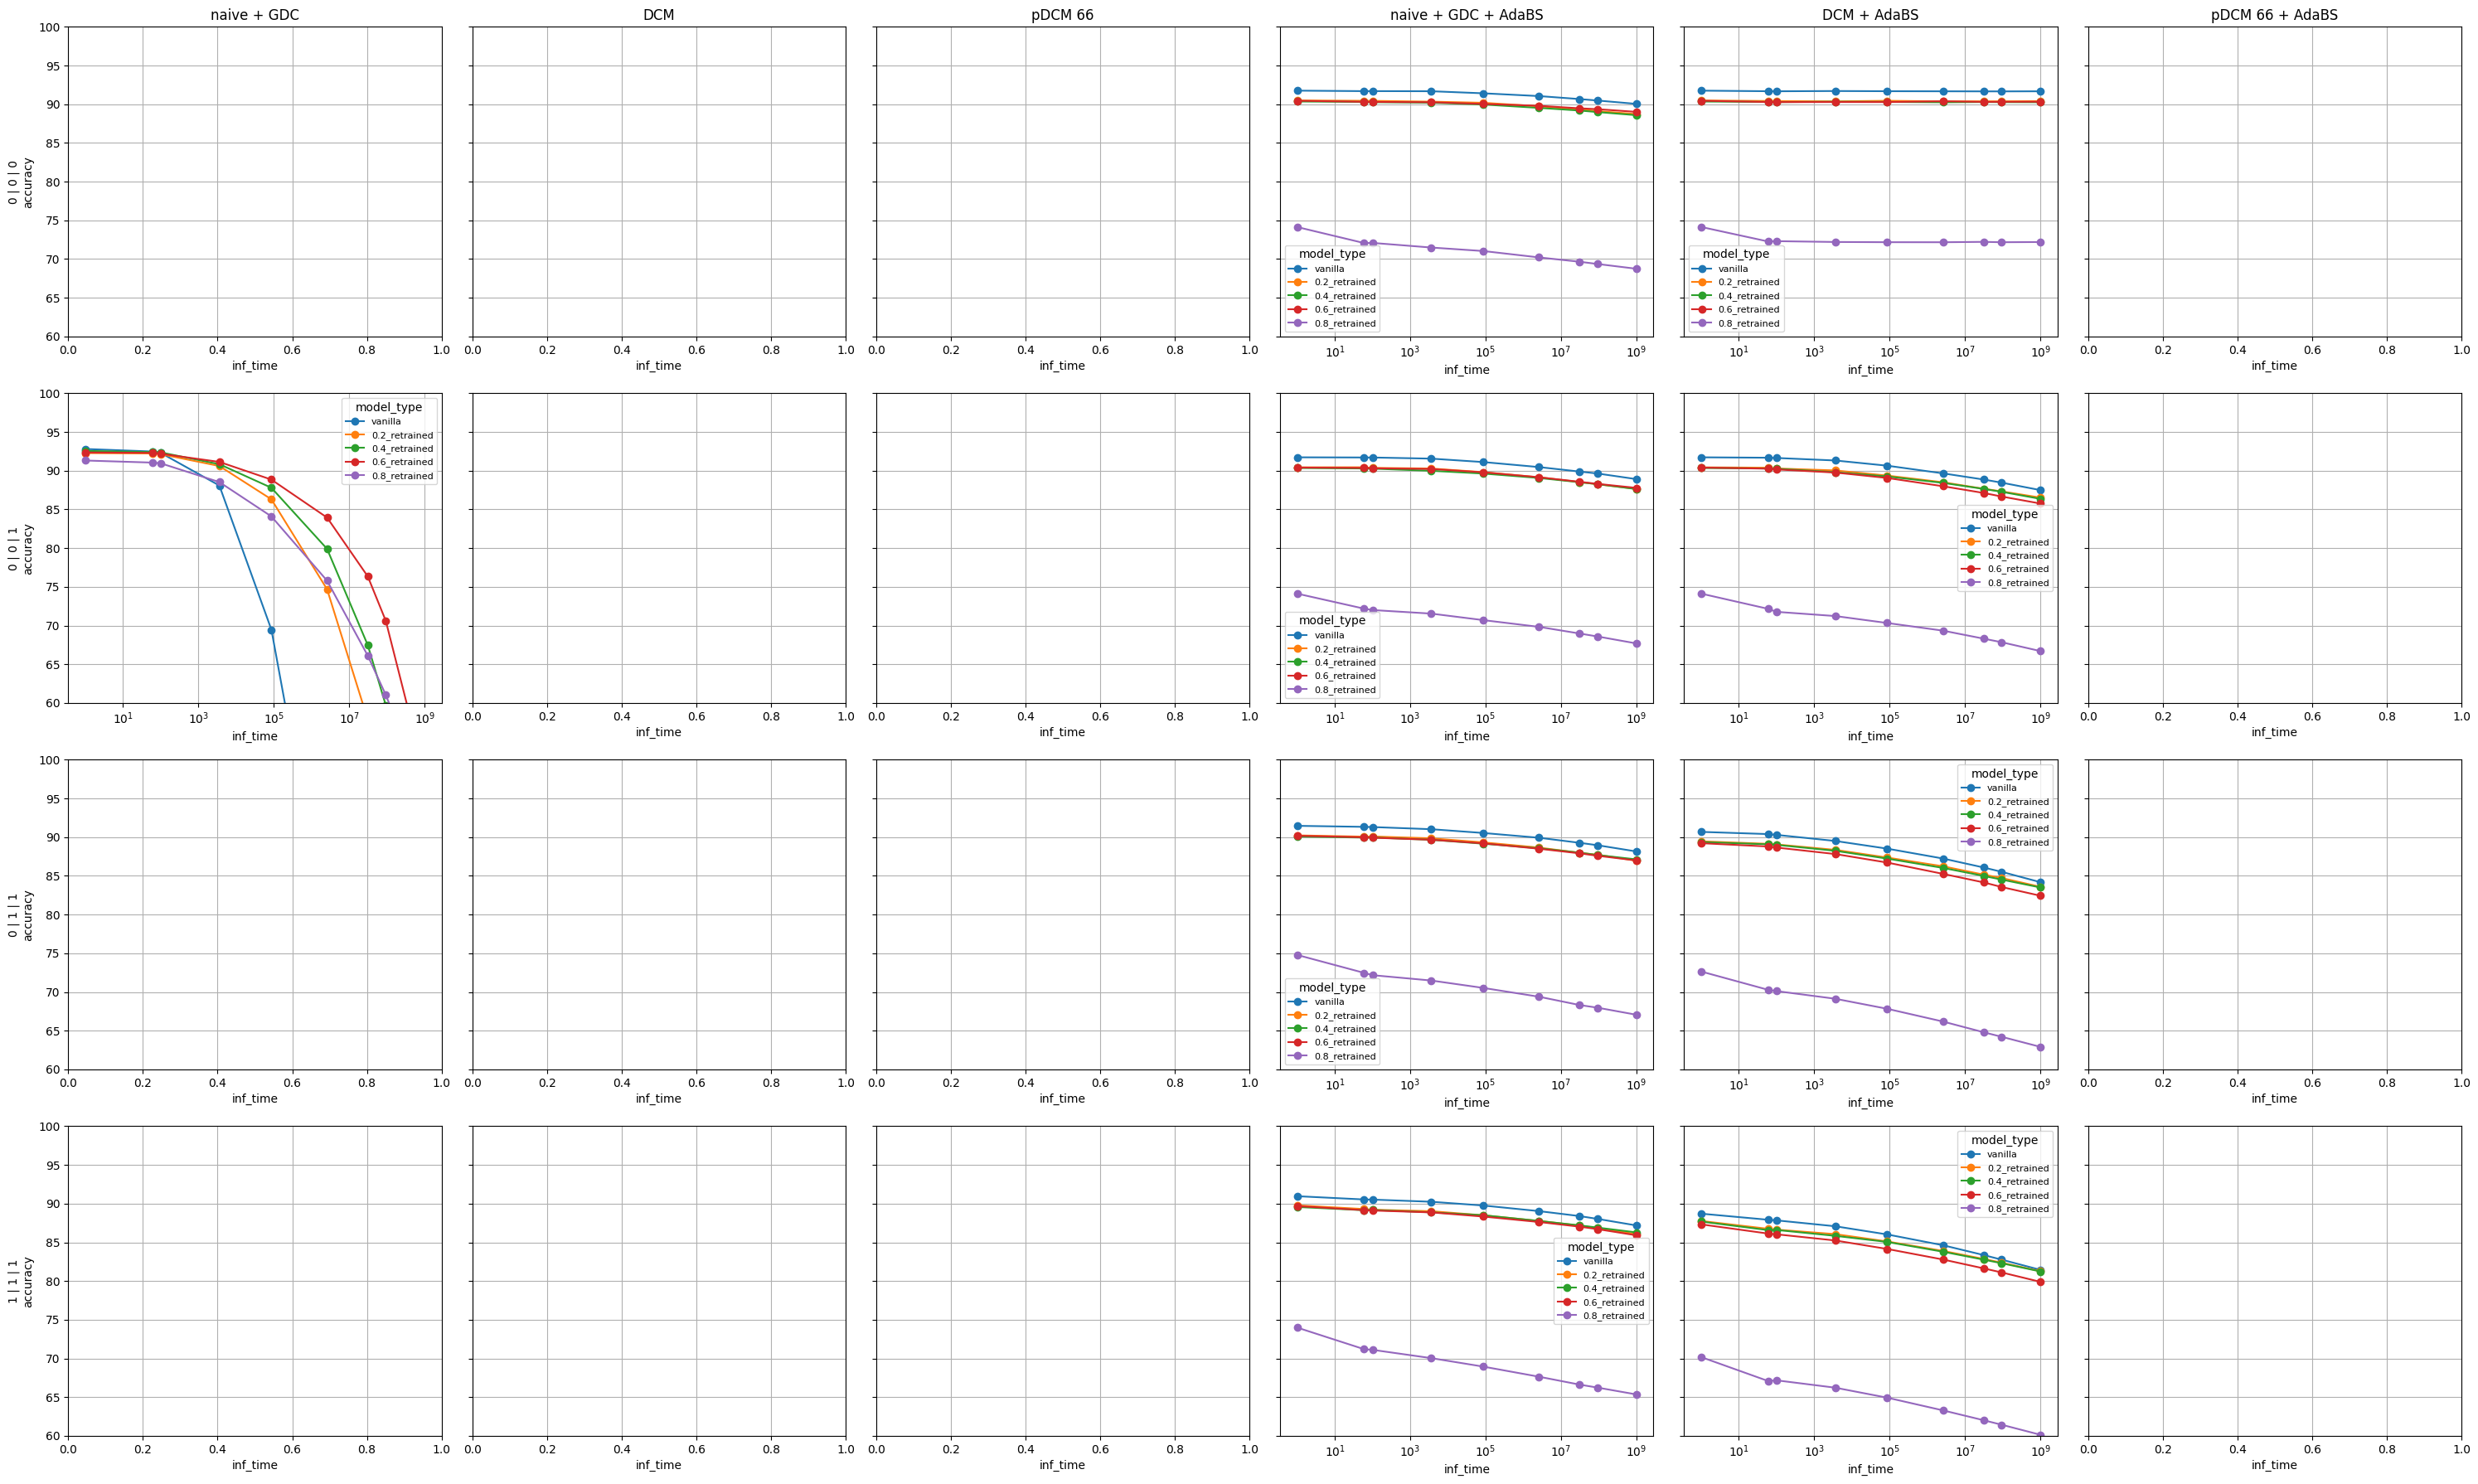

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_filtered = df_raw_io.copy()
df_filtered = df_filtered[df_filtered['GDC'] == 'on']
df_filtered = df_filtered[df_filtered['IOparameter'] == 'non-ideal']
df_filtered = df_filtered[df_filtered['dac_res'] == '7bit']
df_filtered = df_filtered[df_filtered['adc_res'] == '7bit']

def is_missing_like(series):
    return series.isna() | series.astype(str).str.lower().isin(['nan', 'none', '-'])

conditions = [
    (
        'naive + GDC',
        (df_filtered['mapping_method'] == 'naive')
        & (df_filtered['alpha'] == 'GDC')
        & is_missing_like(df_filtered['distortion_f'])
        & is_missing_like(df_filtered['AdaBS'])
    ),
    (
        'DCM',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0')
        & is_missing_like(df_filtered['AdaBS'])
    ),
    (
        'pDCM 66',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0.333')
        & is_missing_like(df_filtered['AdaBS'])
    ),
    (
        'naive + GDC + AdaBS',
        (df_filtered['mapping_method'] == 'naive')
        & (df_filtered['alpha'] == 'GDC')
        & is_missing_like(df_filtered['distortion_f'])
        & (~is_missing_like(df_filtered['AdaBS']))
    ),
    (
        'DCM + AdaBS',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0')
        & (~is_missing_like(df_filtered['AdaBS']))
    ),
    (
        'pDCM 66 + AdaBS',
        (df_filtered['mapping_method'] == 'DCM')
        & (df_filtered['alpha'].astype(str) == '0.024')
        & (df_filtered['distortion_f'].astype(str) == '0.333')
        & (~is_missing_like(df_filtered['AdaBS']))
    ),
]

noise_cols = ['pgm_noise_scale', 'read_noise_scale', 'drift_noise_scale']
condition_dfs = []

for condition_name, condition_mask in conditions:
    condition_df = df_filtered[condition_mask].copy()
    condition_df['condition_name'] = condition_name
    condition_df['noise_label'] = condition_df[noise_cols].apply(
        lambda row: ' | '.join(row.astype(str).tolist()),
        axis=1
    )
    condition_dfs.append(condition_df)

plot_df = pd.concat(condition_dfs, ignore_index=True)

model_type_order = ['vanilla']
remaining_model_types = sorted(
    [m for m in plot_df['model_type'].dropna().unique() if m not in model_type_order]
)
model_types = model_type_order + remaining_model_types

noise_labels = sorted(plot_df['noise_label'].dropna().unique())

cmap = plt.colormaps['tab10']
color_map = {model_type: cmap(i) for i, model_type in enumerate(model_types)}

fig, axes = plt.subplots(
    len(noise_labels),          # row = noise_label
    len(conditions),            # column = condition
    figsize=(5 * len(conditions), 4.5 * len(noise_labels)),
    sharey=True,
    squeeze=False
)

for row_idx, noise_label in enumerate(noise_labels):
    for col_idx, (condition_name, _) in enumerate(conditions):
        ax = axes[row_idx][col_idx]

        subset = plot_df[
            (plot_df['condition_name'] == condition_name) &
            (plot_df['noise_label'] == noise_label)
        ].sort_values('inf_time')

        for model_type in model_types:
            line_df = subset[subset['model_type'] == model_type].sort_values('inf_time')
            if line_df.empty:
                continue

            ax.plot(
                line_df['inf_time'],
                line_df['accuracy'],
                marker='o',
                label=model_type,
                color=color_map[model_type]
            )

        if row_idx == 0:
            ax.set_title(condition_name)

        if col_idx == 0:
            ax.set_ylabel(f'{noise_label}\naccuracy')

        ax.set_xlabel('inf_time')
        ax.grid(True)

        if subset['inf_time'].gt(0).any():
            ax.set_xscale('log')
        
        ax.set_ylim(60, 100)

        if not subset.empty:
            ax.legend(title='model_type', fontsize=8)

plt.tight_layout()
plt.show()